## freezing 8/3/23

In [2]:
from src.MPOptoClass import *
from src.utils.gen_utils import *
from src.utils.filters import *
from src.helpers.experiment import *

import mat73
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.decomposition import PCA


%load_ext autoreload 
%autoreload 2
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. sanity check of opto effects. two way smoothing/one way smoothing/high power lasers/aggregate

In [3]:
pre=100 
post=52
session_path = '/home/diya/Documents/mp_opto/data/vgat2_06062023'

session = MPOptoClass(session_path, pre=pre,  post=post)

/home/diya/Documents/mp_opto/src/helpers/load.py:26: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  CFA['train'] = np.array((CFA['train']))
/home/diya/Documents/mp_opto/src/helpers/load.py:30: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  RFA['train'] = np.array((RFA['train']))


love


## 1a. two way gaussian smoothing, replicating marks sanity checks

In [4]:
fs=1
sigma=10

CFA_trialsmooth, RFA_trialsmooth = session.smoother(bounds=session.laser_bounds[:, [2,3]], sigma=sigma, concat=False, oneway=False)
CFA_ctrlsmooth, RFA_ctrlsmooth =session.smoother(bounds=session.ctrl_bounds[:, [2,3]], sigma=sigma, concat=False, oneway=False)

trial_length = CFA_trialsmooth.shape[0]
num_trials = CFA_trialsmooth.shape[2] 
num_ctrls = CFA_ctrlsmooth.shape[2] 

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


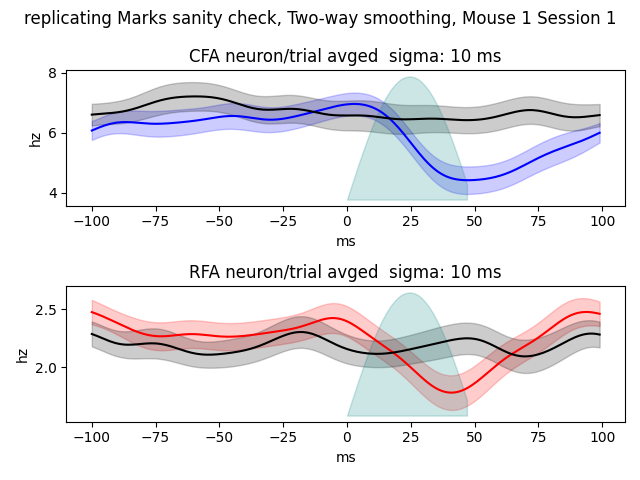

In [5]:
laser_offset = session.laser_bounds[0,1] - session.laser_bounds[0,0]

CFA_sts_avgavg = np.average(CFA_trialsmooth, axis=(1,2)) / (fs/1000)
temp = np.average(CFA_trialsmooth, axis=1)
CFA_sts_avgsem = np.std(temp, axis=1) / np.sqrt(num_trials) / (fs/1000)

RFA_sts_avgavg = np.average(RFA_trialsmooth, axis=(1,2)) / (fs/1000)
temp = np.average(RFA_trialsmooth, axis=1)
RFA_sts_avgsem = np.std(temp, axis=1) / np.sqrt(num_trials) / (fs/1000)

CFA_ctrlsts_avgavg = np.average(CFA_ctrlsmooth, axis=(1,2)) / (fs/1000)
temp = np.average(CFA_ctrlsmooth, axis=1)
CFA_ctrlsts_avgsem = np.std(temp, axis=1) / np.sqrt(num_ctrls) / (fs/1000)

RFA_ctrlsts_avgavg = np.average(RFA_ctrlsmooth, axis=(1,2)) / (fs/1000)
temp = np.average(RFA_ctrlsmooth, axis=1)
RFA_ctrlsts_avgsem = np.std(temp, axis=1) / np.sqrt(num_ctrls) / (fs/1000)

laser_trialmean = np.mean(session.laser_trial_data, axis=1)

x = np.arange(0, trial_length*fs, fs) - pre*fs

fig1a, ax1a = plt.subplots(2, 1)
ax1a[0].plot(x, CFA_sts_avgavg, color='blue')
ax1a[0].plot(x, CFA_ctrlsts_avgavg, color='black')
ax1a[0].fill_between(x, CFA_sts_avgavg - CFA_sts_avgsem, CFA_sts_avgavg + CFA_sts_avgsem, color='blue', alpha=0.2)
ax1a[0].fill_between(x, CFA_ctrlsts_avgavg - CFA_ctrlsts_avgsem, CFA_ctrlsts_avgavg + CFA_ctrlsts_avgsem, color='black', alpha=0.2)
#ax1a[0].axvspan(0, laser_offset, color='teal', alpha=0.2)
cfa_ymin = ax1a[0].get_ylim()[0]
cfa_ymax = ax1a[0].get_ylim()[1]
cfa_laser = normalizeDataToRange(laser_trialmean, (cfa_ymin, cfa_ymax))
cfa_laser_x = np.arange(0,48)
ax1a[0].fill_between(cfa_laser_x, cfa_ymin, cfa_laser, color='teal', alpha=0.2)
ax1a[0].set_ylabel('hz')
ax1a[0].set_title(f'CFA neuron/trial avged  sigma: {sigma} ms')
ax1a[0].set_xlabel('ms')

ax1a[1].plot(x, RFA_sts_avgavg, color='red')
ax1a[1].plot(x, RFA_ctrlsts_avgavg, color='black')
ax1a[1].fill_between(x, RFA_sts_avgavg - RFA_sts_avgsem, RFA_sts_avgavg + RFA_sts_avgsem, color='red', alpha=0.2)
ax1a[1].fill_between(x, RFA_ctrlsts_avgavg - RFA_ctrlsts_avgsem, RFA_ctrlsts_avgavg + RFA_ctrlsts_avgsem, color='black', alpha=0.2)
rfa_ymin = ax1a[1].get_ylim()[0]
rfa_ymax = ax1a[1].get_ylim()[1]
rfa_laser = normalizeDataToRange(laser_trialmean, (rfa_ymin, rfa_ymax))
rfa_laser_x = np.arange(0,48)
ax1a[1].fill_between(rfa_laser_x, rfa_ymin, rfa_laser, color='teal', alpha=0.2)
ax1a[1].set_ylabel('hz')
ax1a[1].set_title(f'RFA neuron/trial avged  sigma: {sigma} ms')
ax1a[1].set_xlabel('ms')
ax1a[1].set_ylabel('hz')

fig1a.suptitle('replicating Marks sanity check, Two-way smoothing, Mouse 1 Session 1')


fig1a.tight_layout()

## 1b. how does it look with one-way smoothing

In [6]:
fs=1
sigma=10

CFA_trialsmooth, RFA_trialsmooth = session.smoother(bounds=session.laser_bounds[:, [2,3]], sigma=sigma, concat=False, oneway=True)
CFA_ctrlsmooth, RFA_ctrlsmooth =session.smoother(bounds=session.ctrl_bounds[:, [2,3]], sigma=sigma, concat=False, oneway=True)

trial_length = CFA_trialsmooth.shape[0]
num_trials = CFA_trialsmooth.shape[2] 
num_ctrls = CFA_ctrlsmooth.shape[2] 

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


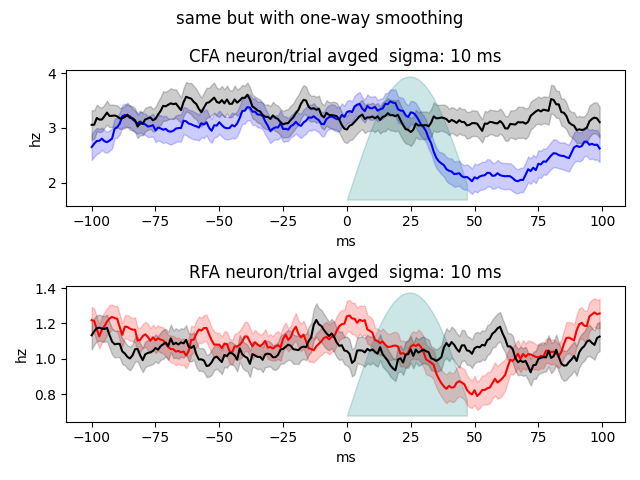

In [7]:
laser_trialmean = np.mean(session.laser_trial_data, axis=1)
laser_offset = session.laser_bounds[0,1] - session.laser_bounds[0,0]

CFA_sts_avgavg = np.average(CFA_trialsmooth, axis=(1,2)) / (fs/1000)
temp = np.average(CFA_trialsmooth, axis=1)
CFA_sts_avgsem = np.std(temp, axis=1) / np.sqrt(num_trials) / (fs/1000)

RFA_sts_avgavg = np.average(RFA_trialsmooth, axis=(1,2)) / (fs/1000)
temp = np.average(RFA_trialsmooth, axis=1)
RFA_sts_avgsem = np.std(temp, axis=1) / np.sqrt(num_trials) / (fs/1000)

CFA_ctrlsts_avgavg = np.average(CFA_ctrlsmooth, axis=(1,2)) / (fs/1000)
temp = np.average(CFA_ctrlsmooth, axis=1)
CFA_ctrlsts_avgsem = np.std(temp, axis=1) / np.sqrt(num_ctrls) / (fs/1000)

RFA_ctrlsts_avgavg = np.average(RFA_ctrlsmooth, axis=(1,2)) / (fs/1000)
temp = np.average(RFA_ctrlsmooth, axis=1)
RFA_ctrlsts_avgsem = np.std(temp, axis=1) / np.sqrt(num_ctrls) / (fs/1000)

x = np.arange(0, trial_length*fs, fs) - pre*fs

fig1b, ax1b = plt.subplots(2, 1)
ax1b[0].plot(x, CFA_sts_avgavg, color='blue')
ax1b[0].plot(x, CFA_ctrlsts_avgavg, color='black')
ax1b[0].fill_between(x, CFA_sts_avgavg - CFA_sts_avgsem, CFA_sts_avgavg + CFA_sts_avgsem, color='blue', alpha=0.2)
ax1b[0].fill_between(x, CFA_ctrlsts_avgavg - CFA_ctrlsts_avgsem, CFA_ctrlsts_avgavg + CFA_ctrlsts_avgsem, color='black', alpha=0.2)
cfa_ymin = ax1b[0].get_ylim()[0]
cfa_ymax = ax1b[0].get_ylim()[1]
cfa_laser = normalizeDataToRange(laser_trialmean, (cfa_ymin, cfa_ymax))
cfa_laser_x = np.arange(0,48)
ax1b[0].fill_between(cfa_laser_x, cfa_ymin, cfa_laser, color='teal', alpha=0.2)
ax1b[0].set_ylabel('hz')
ax1b[0].set_title(f'CFA neuron/trial avged  sigma: {sigma} ms')
ax1b[0].set_xlabel('ms')

ax1b[1].plot(x, RFA_sts_avgavg, color='red')
ax1b[1].plot(x, RFA_ctrlsts_avgavg, color='black')
ax1b[1].fill_between(x, RFA_sts_avgavg - RFA_sts_avgsem, RFA_sts_avgavg + RFA_sts_avgsem, color='red', alpha=0.2)
ax1b[1].fill_between(x, RFA_ctrlsts_avgavg - RFA_ctrlsts_avgsem, RFA_ctrlsts_avgavg + RFA_ctrlsts_avgsem, color='black', alpha=0.2)
rfa_ymin = ax1b[1].get_ylim()[0]
rfa_ymax = ax1b[1].get_ylim()[1]
rfa_laser = normalizeDataToRange(laser_trialmean, (rfa_ymin, rfa_ymax))
rfa_laser_x = np.arange(0,48)
ax1b[1].fill_between(rfa_laser_x, rfa_ymin, rfa_laser, color='teal', alpha=0.2)
ax1b[1].set_title(f'RFA neuron/trial avged  sigma: {sigma} ms')
ax1b[1].set_xlabel('ms')
ax1b[1].set_ylabel('hz')

fig1b.suptitle('same but with one-way smoothing')


fig1b.tight_layout()

## 1c. and only looking at high laser powers?

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


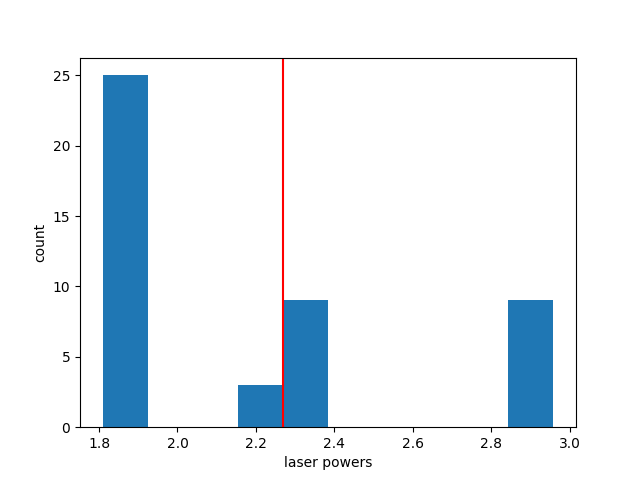

In [8]:
fig1c0, ax1c0 = plt.subplots()
counts, edges, nada = ax1c0.hist(session.laser_powers)
ax1c0.set_xlabel('laser powers')
ax1c0.set_ylabel('count')
laser_power_threshold = edges[4]
np.count_nonzero(session.laser_powers > laser_power_threshold)
ax1c0.axvline(edges[4], color='red')

laser_highbounds = session.laser_bounds[session.laser_powers > laser_power_threshold, :]

In [9]:
fs=1
sigma=10

CFA_trialsmooth, RFA_trialsmooth = session.smoother(bounds=laser_highbounds[:, [2,3]], sigma=sigma, concat=False, oneway=True)
CFA_ctrlsmooth, RFA_ctrlsmooth =session.smoother(bounds=session.ctrl_bounds[:, [2,3]], sigma=sigma, concat=False, oneway=True)

trial_length = CFA_trialsmooth.shape[0]
num_trials = CFA_trialsmooth.shape[2] 
num_ctrls = CFA_ctrlsmooth.shape[2] 

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


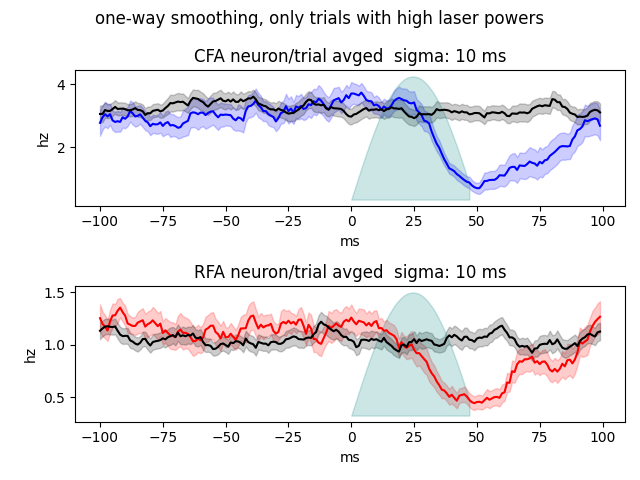

In [10]:
laser_trialmean = np.mean(session.laser_trial_data[:, session.laser_powers > laser_power_threshold], axis=1)
laser_offset = session.laser_bounds[0,1] - session.laser_bounds[0,0]

CFA_sts_avgavg = np.average(CFA_trialsmooth, axis=(1,2)) / (fs/1000)
temp = np.average(CFA_trialsmooth, axis=1)
CFA_sts_avgsem = np.std(temp, axis=1) / np.sqrt(num_trials) / (fs/1000)

RFA_sts_avgavg = np.average(RFA_trialsmooth, axis=(1,2)) / (fs/1000)
temp = np.average(RFA_trialsmooth, axis=1)
RFA_sts_avgsem = np.std(temp, axis=1) / np.sqrt(num_trials) / (fs/1000)

CFA_ctrlsts_avgavg = np.average(CFA_ctrlsmooth, axis=(1,2)) / (fs/1000)
temp = np.average(CFA_ctrlsmooth, axis=1)
CFA_ctrlsts_avgsem = np.std(temp, axis=1) / np.sqrt(num_ctrls) / (fs/1000)

RFA_ctrlsts_avgavg = np.average(RFA_ctrlsmooth, axis=(1,2)) / (fs/1000)
temp = np.average(RFA_ctrlsmooth, axis=1)
RFA_ctrlsts_avgsem = np.std(temp, axis=1) / np.sqrt(num_ctrls) / (fs/1000)

cfa_laser = normalizeDataToRange(laser_trialmean, (0, np.max(CFA_sts_avgavg)))
cfa_laser_x = np.arange(0,48)

rfa_laser = normalizeDataToRange(laser_trialmean, (0, np.max(RFA_sts_avgavg)))
rfa_laser_x = np.arange(0,48)
x = np.arange(0, trial_length*fs, fs) - pre*fs

fig1c, ax1c = plt.subplots(2, 1)
ax1c[0].plot(x, CFA_sts_avgavg, color='blue')
ax1c[0].plot(x, CFA_ctrlsts_avgavg, color='black')
ax1c[0].fill_between(x, CFA_sts_avgavg - CFA_sts_avgsem, CFA_sts_avgavg + CFA_sts_avgsem, color='blue', alpha=0.2)
ax1c[0].fill_between(x, CFA_ctrlsts_avgavg - CFA_ctrlsts_avgsem, CFA_ctrlsts_avgavg + CFA_ctrlsts_avgsem, color='black', alpha=0.2)
cfa_ymin = ax1c[0].get_ylim()[0]
cfa_ymax = ax1c[0].get_ylim()[1]
cfa_laser = normalizeDataToRange(laser_trialmean, (cfa_ymin, cfa_ymax))
cfa_laser_x = np.arange(0,48)
ax1c[0].fill_between(cfa_laser_x, cfa_ymin, cfa_laser, color='teal', alpha=0.2)
ax1c[0].set_ylabel('hz')
ax1c[0].set_title(f'CFA neuron/trial avged  sigma: {sigma} ms')
ax1c[0].set_xlabel('ms')

ax1c[1].plot(x, RFA_sts_avgavg, color='red')
ax1c[1].plot(x, RFA_ctrlsts_avgavg, color='black')
ax1c[1].fill_between(x, RFA_sts_avgavg - RFA_sts_avgsem, RFA_sts_avgavg + RFA_sts_avgsem, color='red', alpha=0.2)
ax1c[1].fill_between(x, RFA_ctrlsts_avgavg - RFA_ctrlsts_avgsem, RFA_ctrlsts_avgavg + RFA_ctrlsts_avgsem, color='black', alpha=0.2)
rfa_ymin = ax1c[1].get_ylim()[0]
rfa_ymax = ax1c[1].get_ylim()[1]
rfa_laser = normalizeDataToRange(laser_trialmean, (rfa_ymin, rfa_ymax))
rfa_laser_x = np.arange(0,48)
ax1c[1].fill_between(rfa_laser_x, rfa_ymin, rfa_laser, color='teal', alpha=0.2)
ax1c[1].set_title(f'RFA neuron/trial avged  sigma: {sigma} ms')
ax1c[1].set_xlabel('ms')
ax1c[1].set_ylabel('hz')

fig1c.suptitle('one-way smoothing, only trials with high laser powers')

fig1c.tight_layout()

## 1d. what happens if we combine across all sessions

In [11]:
pre=100 
post=52
session1_path = '/home/diya/Documents/mp_opto/data/vgat2_06062023'
session2_path = '/home/diya/Documents/mp_opto/data/vgat2_06072023'
session3_path = '/home/diya/Documents/mp_opto/data/vgat4_06202023'
session4_path = '/home/diya/Documents/mp_opto/data/vgat4_06212023'

session1 = MPOptoClass(session1_path, pre=pre,  post=post)
session2 = MPOptoClass(session2_path, pre=pre,  post=post)
session3 = MPOptoClass(session3_path, pre=pre,  post=post)
session4 = MPOptoClass(session4_path, pre=pre,  post=post)

love
love
love
love


In [12]:
CFA1_trial, RFA1_trial = session1.smoother(bounds=session1.laser_bounds[:, [2,3]], sigma=sigma, concat=False, oneway=True)
CFA1_trial_avgneu = np.average(CFA1_trial, axis=1)
RFA1_trial_avgneu = np.average(RFA1_trial, axis=1)
CFA1_ctrl, RFA1_ctrl =session1.smoother(bounds=session1.ctrl_bounds[:, [2,3]], sigma=sigma, concat=False, oneway=True)
CFA1_ctrl_avgneu = np.average(CFA1_ctrl, axis=1)
RFA1_ctrl_avgneu = np.average(RFA1_ctrl, axis=1)

CFA2_trial, RFA2_trial = session2.smoother(bounds=session2.laser_bounds[:, [2,3]], sigma=sigma, concat=False, oneway=True)
CFA2_trial_avgneu = np.average(CFA2_trial, axis=1)
RFA2_trial_avgneu = np.average(RFA2_trial, axis=1)
CFA2_ctrl, RFA2_ctrl =session2.smoother(bounds=session2.ctrl_bounds[:, [2,3]], sigma=sigma, concat=False, oneway=True)
CFA2_ctrl_avgneu = np.average(CFA2_ctrl, axis=1)
RFA2_ctrl_avgneu = np.average(RFA2_ctrl, axis=1)

CFA3_trial, RFA3_trial = session3.smoother(bounds=session3.laser_bounds[:, [2,3]], sigma=sigma, concat=False, oneway=True)
CFA3_trial_avgneu = np.average(CFA3_trial, axis=1)
RFA3_trial_avgneu = np.average(RFA3_trial, axis=1)
CFA3_ctrl, RFA3_ctrl =session3.smoother(bounds=session3.ctrl_bounds[:, [2,3]], sigma=sigma, concat=False, oneway=True)
CFA3_ctrl_avgneu = np.average(CFA3_ctrl, axis=1)
RFA3_ctrl_avgneu = np.average(RFA3_ctrl, axis=1)

CFA4_trial, RFA4_trial = session4.smoother(bounds=session4.laser_bounds[:, [2,3]], sigma=sigma, concat=False, oneway=True)
CFA4_trial_avgneu = np.average(CFA4_trial, axis=1)
RFA4_trial_avgneu = np.average(RFA4_trial, axis=1)
CFA4_ctrl, RFA4_ctrl =session4.smoother(bounds=session4.ctrl_bounds[:, [2,3]], sigma=sigma, concat=False, oneway=True)
CFA4_ctrl_avgneu = np.average(CFA4_ctrl, axis=1)
RFA4_ctrl_avgneu = np.average(RFA4_ctrl, axis=1)


In [13]:
CFA_all = np.hstack((CFA1_trial_avgneu, CFA2_trial_avgneu, CFA3_trial_avgneu, CFA4_trial_avgneu))
RFA_all = np.hstack((RFA1_trial_avgneu, CFA2_trial_avgneu, RFA3_trial_avgneu, RFA4_trial_avgneu))

CFA_ctrl_all = np.hstack((CFA1_ctrl_avgneu, CFA2_trial_avgneu, CFA3_ctrl_avgneu, CFA4_ctrl_avgneu))
RFA_ctrl_all = np.hstack((RFA1_ctrl_avgneu, CFA2_trial_avgneu, RFA3_ctrl_avgneu, RFA4_ctrl_avgneu))


print(CFA_all.shape)
print(CFA_ctrl_all.shape)

num_trials = CFA_all.shape[1]
num_ctrls = CFA_ctrl_all.shape[1]


(200, 159)
(200, 148)


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


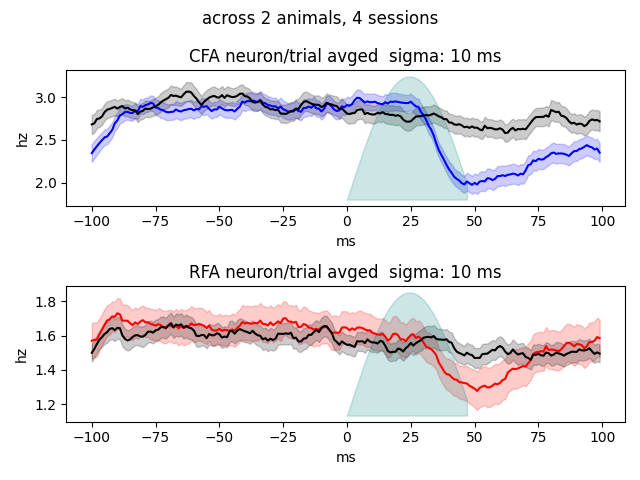

In [14]:
laser_trialmean = np.mean(session1.laser_trial_data, axis=1)
laser_offset = session1.laser_bounds[0,1] - session1.laser_bounds[0,0]

CFA_sts_avgavg = np.average(CFA_all, axis=1) / (fs/1000)
CFA_sts_avgsem = np.std(CFA_all, axis=1) / np.sqrt(num_trials) / (fs/1000)

RFA_sts_avgavg = np.average(RFA_all, axis=1) / (fs/1000)
RFA_sts_avgsem = np.std(CFA_all, axis=1) / np.sqrt(num_trials) / (fs/1000)

CFA_ctrlsts_avgavg = np.average(CFA_ctrl_all, axis=1) / (fs/1000)
CFA_ctrlsts_avgsem = np.std(CFA_ctrl_all, axis=1) / np.sqrt(num_ctrls) / (fs/1000)

RFA_ctrlsts_avgavg = np.average(RFA_ctrl_all, axis=1) / (fs/1000)
RFA_ctrlsts_avgsem = np.std(RFA_ctrl_all, axis=1) / np.sqrt(num_ctrls) / (fs/1000)

x = np.arange(0, trial_length*fs, fs) - pre*fs

fig1d, ax1d = plt.subplots(2, 1)
ax1d[0].plot(x, CFA_sts_avgavg, color='blue')
ax1d[0].plot(x, CFA_ctrlsts_avgavg, color='black')
ax1d[0].fill_between(x, CFA_sts_avgavg - CFA_sts_avgsem, CFA_sts_avgavg + CFA_sts_avgsem, color='blue', alpha=0.2)
ax1d[0].fill_between(x, CFA_ctrlsts_avgavg - CFA_ctrlsts_avgsem, CFA_ctrlsts_avgavg + CFA_ctrlsts_avgsem, color='black', alpha=0.2)
cfa_ymin = ax1d[0].get_ylim()[0]
cfa_ymax = ax1d[0].get_ylim()[1]
cfa_laser = normalizeDataToRange(laser_trialmean, (cfa_ymin, cfa_ymax))
cfa_laser_x = np.arange(0,48)
ax1d[0].fill_between(cfa_laser_x, cfa_ymin, cfa_laser, color='teal', alpha=0.2)
ax1d[0].set_ylabel('hz')
ax1d[0].set_title(f'CFA neuron/trial avged  sigma: {sigma} ms')
ax1d[0].set_xlabel('ms')

ax1d[1].plot(x, RFA_sts_avgavg, color='red')
ax1d[1].plot(x, RFA_ctrlsts_avgavg, color='black')
ax1d[1].fill_between(x, RFA_sts_avgavg - RFA_sts_avgsem, RFA_sts_avgavg + RFA_sts_avgsem, color='red', alpha=0.2)
ax1d[1].fill_between(x, RFA_ctrlsts_avgavg - RFA_ctrlsts_avgsem, RFA_ctrlsts_avgavg + RFA_ctrlsts_avgsem, color='black', alpha=0.2)
rfa_ymin = ax1d[1].get_ylim()[0]
rfa_ymax = ax1d[1].get_ylim()[1]
rfa_laser = normalizeDataToRange(laser_trialmean, (rfa_ymin, rfa_ymax))
rfa_laser_x = np.arange(0,48)
ax1d[1].fill_between(rfa_laser_x, rfa_ymin, rfa_laser, color='teal', alpha=0.2)
ax1d[1].set_title(f'RFA neuron/trial avged  sigma: {sigma} ms')
ax1d[1].set_xlabel('ms')
ax1d[1].set_ylabel('hz')

fig1d.suptitle('across 2 animals, 4 sessions')
fig1d.tight_layout()

# 2. does population structure change during laser trials?

In [ ]:
pre=20
post=52
sigma=10
session_path = '/home/diya/Documents/mp_opto/data/vgat2_06062023'

session = MPOptoClass(session_path, pre=pre,  post=post)

## 2a. lets find climbing PC space and laser PC space

In [16]:
CFA_climbPCAobj, RFA_climbPCAobj = session.apply_PCA(bounds=session.climbing_bounds, sigma=sigma)
CFA_trialPCAobj, RFA_trialPCAobj = session.apply_PCA(bounds=session.laser_bounds[:, [0, 3]], sigma=sigma)

In [17]:
CFA_trialsmooth, RFA_trialsmooth = session.smoother(bounds = session.laser_bounds[:,[0,3]], sigma=sigma, oneway=True, concat=True)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


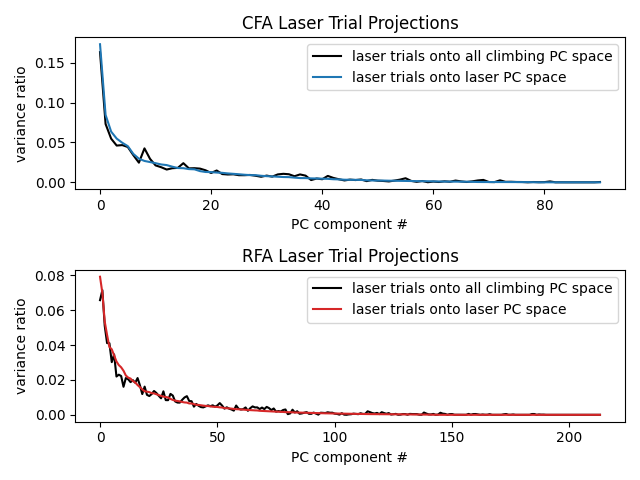

In [18]:
CFA_trial_climbPCA = CFA_climbPCAobj.transform(CFA_trialsmooth)
CFA_trial_trialPCA = CFA_trialPCAobj.transform(CFA_trialsmooth)

CFA_trial_totalvar = np.sum(np.var(CFA_trialsmooth, axis=0))

CFA_trial_climbPCA_var = np.var(CFA_trial_climbPCA, axis=0)
CFA_trial_trialPCA_var = np.var(CFA_trial_trialPCA, axis=0)

CFA_trial_climbPCA_varatio = CFA_trial_climbPCA_var / CFA_trial_totalvar
CFA_trial_trialPCA_varatio = CFA_trial_trialPCA_var / CFA_trial_totalvar

fig2a, ax2a= plt.subplots(2, 1)
ax2a[0].set_title('CFA Laser Trial Projections')
ax2a[0].plot(CFA_trial_climbPCA_varatio, color='black', label='laser trials onto all climbing PC space')
ax2a[0].plot(CFA_trial_trialPCA_varatio, color='tab:blue', label='laser trials onto laser PC space')
ax2a[0].set_ylabel('variance ratio')
ax2a[0].set_xlabel('PC component #')
ax2a[0].legend()

RFA_trial_climbPCA = RFA_climbPCAobj.transform(RFA_trialsmooth)
RFA_trial_trialPCA = RFA_trialPCAobj.transform(RFA_trialsmooth)

RFA_trial_totalvar = np.sum(np.var(RFA_trialsmooth, axis=0))

RFA_trial_climbPCA_var = np.var(RFA_trial_climbPCA, axis=0)
RFA_trial_trialPCA_var = np.var(RFA_trial_trialPCA, axis=0)

RFA_trial_climbPCA_varatio = RFA_trial_climbPCA_var / RFA_trial_totalvar
RFA_trial_trialPCA_varatio = RFA_trial_trialPCA_var / RFA_trial_totalvar

ax2a[1].set_title('RFA Laser Trial Projections')
ax2a[1].plot(RFA_trial_climbPCA_varatio, color='black', label='laser trials onto all climbing PC space')
ax2a[1].plot(RFA_trial_trialPCA_varatio, color='tab:red', label='laser trials onto laser PC space')
ax2a[1].set_ylabel('variance ratio')
ax2a[1].set_xlabel('PC component #')
ax2a[1].legend()

fig2a.tight_layout()

## 2b. what happens if we project all climbing data onto both spaces

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


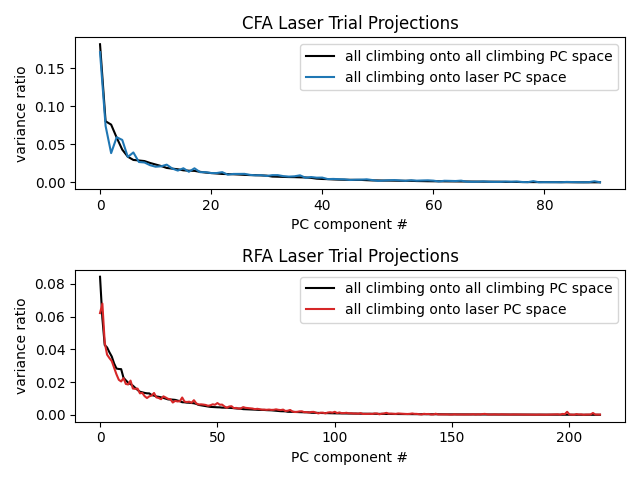

In [19]:
CFA_climbsmooth, RFA_climbsmooth = session.smoother(bounds = session.climbing_bounds, sigma=sigma, concat=True)

CFA_climb_climbPCA = CFA_climbPCAobj.transform(CFA_climbsmooth)
CFA_climb_trialPCA = CFA_trialPCAobj.transform(CFA_climbsmooth)

CFA_climb_totalvar = np.sum(np.var(CFA_climbsmooth, axis=0))

CFA_climb_climbPCA_var = np.var(CFA_climb_climbPCA, axis=0)
CFA_climb_trialPCA_var = np.var(CFA_climb_trialPCA, axis=0)

CFA_climb_climbPCA_varatio = CFA_climb_climbPCA_var / CFA_climb_totalvar
CFA_climb_trialPCA_varatio = CFA_climb_trialPCA_var / CFA_climb_totalvar

fig2b, ax2b = plt.subplots(2, 1)
ax2b[0].set_title('CFA Laser Trial Projections')
ax2b[0].plot(CFA_climb_climbPCA_varatio, color='black', label='all climbing onto all climbing PC space')
ax2b[0].plot(CFA_climb_trialPCA_varatio, color='tab:blue', label='all climbing onto laser PC space')
ax2b[0].set_ylabel('variance ratio')
ax2b[0].set_xlabel('PC component #')
ax2b[0].legend()

RFA_climb_climbPCA = RFA_climbPCAobj.transform(RFA_climbsmooth)
RFA_climb_trialPCA = RFA_trialPCAobj.transform(RFA_climbsmooth)

RFA_climb_totalvar = np.sum(np.var(RFA_climbsmooth, axis=0))

RFA_climb_climbPCA_var = np.var(RFA_climb_climbPCA, axis=0)
RFA_climb_trialPCA_var = np.var(RFA_climb_trialPCA, axis=0)

RFA_climb_climbPCA_varatio = RFA_climb_climbPCA_var / RFA_climb_totalvar
RFA_climb_trialPCA_varatio = RFA_climb_trialPCA_var / RFA_climb_totalvar

ax2b[1].set_title('RFA Laser Trial Projections')
ax2b[1].plot(RFA_climb_climbPCA_varatio, color='black', label='all climbing onto all climbing PC space')
ax2b[1].plot(RFA_climb_trialPCA_varatio, color='tab:red', label='all climbing onto laser PC space')
ax2b[1].set_ylabel('variance ratio')
ax2b[1].set_xlabel('PC component #')
ax2b[1].legend()

fig2b.tight_layout()

## 2c. does this change with only high laser powers?

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


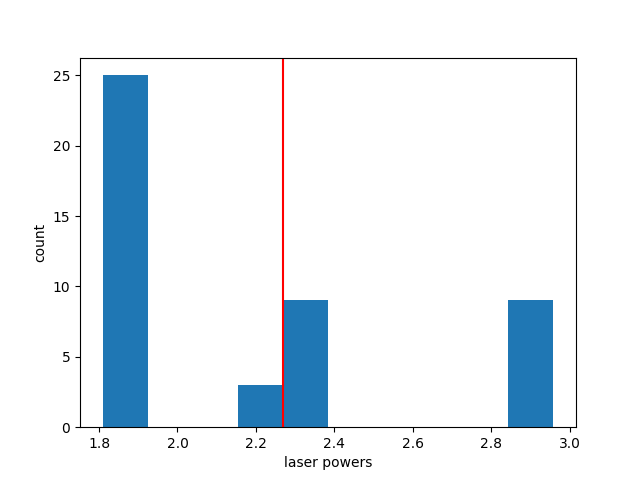

In [20]:
fig2c0, ax2c0 = plt.subplots()
counts, edges, nada = ax2c0.hist(session.laser_powers)
ax2c0.set_xlabel('laser powers')
ax2c0.set_ylabel('count')
laser_power_threshold = edges[4]
np.count_nonzero(session.laser_powers > laser_power_threshold)
ax2c0.axvline(edges[4], color='red')
laser_highbounds = session.laser_bounds[session.laser_powers > laser_power_threshold, :]

In [21]:
CFA_climbPCAobj, RFA_climbPCAobj = session.apply_PCA(bounds=session.climbing_bounds, sigma=sigma)
CFA_trialPCAobj, RFA_trialPCAobj = session.apply_PCA(bounds=laser_highbounds[:, [0, 3]], sigma=sigma)

In [22]:
CFA_trialsmooth, RFA_trialsmooth = session.smoother(bounds = laser_highbounds[:,[0,3]], sigma=sigma, oneway=True, concat=True)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


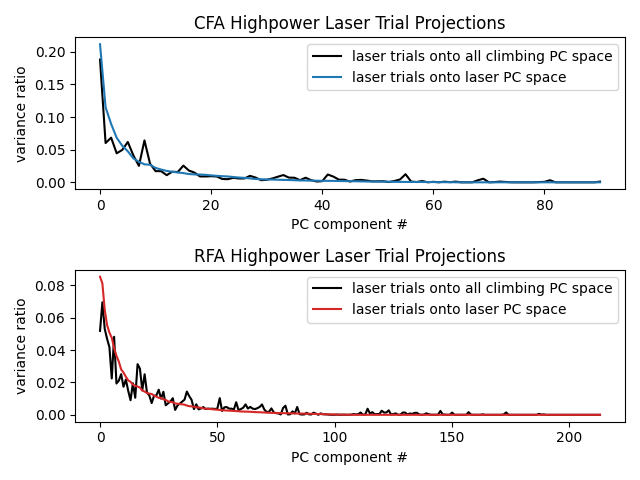

In [23]:
CFA_trial_climbPCA = CFA_climbPCAobj.transform(CFA_trialsmooth)
CFA_trial_trialPCA = CFA_trialPCAobj.transform(CFA_trialsmooth)

CFA_trial_totalvar = np.sum(np.var(CFA_trialsmooth, axis=0))

CFA_trial_climbPCA_var = np.var(CFA_trial_climbPCA, axis=0)
CFA_trial_trialPCA_var = np.var(CFA_trial_trialPCA, axis=0)

CFA_trial_climbPCA_varatio = CFA_trial_climbPCA_var / CFA_trial_totalvar
CFA_trial_trialPCA_varatio = CFA_trial_trialPCA_var / CFA_trial_totalvar

fig2c, ax2c= plt.subplots(2, 1)
ax2c[0].set_title('CFA Highpower Laser Trial Projections')
ax2c[0].plot(CFA_trial_climbPCA_varatio, color='black', label='laser trials onto all climbing PC space')
ax2c[0].plot(CFA_trial_trialPCA_varatio, color='tab:blue', label='laser trials onto laser PC space')
ax2c[0].set_ylabel('variance ratio')
ax2c[0].set_xlabel('PC component #')
ax2c[0].legend()

RFA_trial_climbPCA = RFA_climbPCAobj.transform(RFA_trialsmooth)
RFA_trial_trialPCA = RFA_trialPCAobj.transform(RFA_trialsmooth)

RFA_trial_totalvar = np.sum(np.var(RFA_trialsmooth, axis=0))

RFA_trial_climbPCA_var = np.var(RFA_trial_climbPCA, axis=0)
RFA_trial_trialPCA_var = np.var(RFA_trial_trialPCA, axis=0)

RFA_trial_climbPCA_varatio = RFA_trial_climbPCA_var / RFA_trial_totalvar
RFA_trial_trialPCA_varatio = RFA_trial_trialPCA_var / RFA_trial_totalvar

ax2c[1].set_title('RFA Highpower Laser Trial Projections')
ax2c[1].plot(RFA_trial_climbPCA_varatio, color='black', label='laser trials onto all climbing PC space')
ax2c[1].plot(RFA_trial_trialPCA_varatio, color='tab:red', label='laser trials onto laser PC space')
ax2c[1].set_ylabel('variance ratio')
ax2c[1].set_xlabel('PC component #')
ax2c[1].legend()

fig2c.tight_layout()

# do first few components in laser space capture drop in activity?

In [30]:
CFA_psthsmooth, RFA_psthsmooth = session.smoother(session.laser_bounds[:,2:], sigma=sigma, concat=True)
CFA_ctrlpsthsmooth, RFA_ctrlpsthsmooth = session.smoother(session.ctrl_bounds[:,2:], sigma=sigma, concat=True)

CFA_psthsmooth_PCA = unstitchBounds(CFA_trialPCAobj.transform(CFA_psthsmooth), session.laser_bounds[:,2:])
RFA_psthsmooth_PCA = unstitchBounds(RFA_trialPCAobj.transform(RFA_psthsmooth), session.laser_bounds[:,2:])

CFA_ctrlsmooth_PCA = unstitchBounds(CFA_trialPCAobj.transform(CFA_ctrlpsthsmooth), session.ctrl_bounds[:,2:])
RFA_ctrlsmooth_PCA = unstitchBounds(RFA_trialPCAobj.transform(RFA_ctrlpsthsmooth), session.ctrl_bounds[:,2:])

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


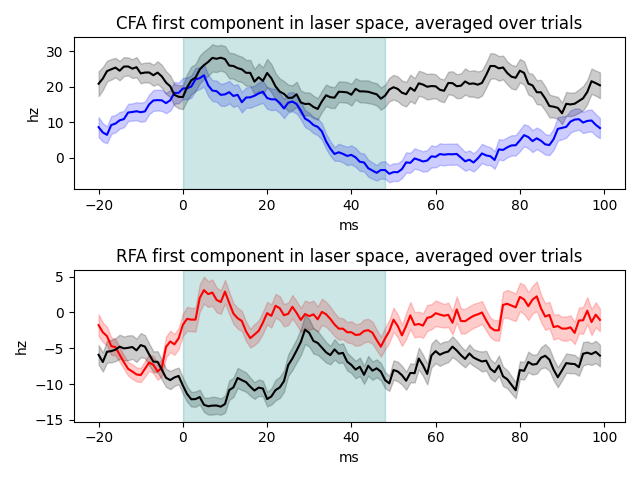

In [31]:
pre=20
trial_length = CFA_psthsmooth_PCA.shape[0]
laser_offset = session.laser_bounds[0,1] - session.laser_bounds[0,0]

CFA_comp1 = CFA_psthsmooth_PCA[:,0,:]
CFA_comp1_avg = np.average(CFA_comp1, axis=1) / (fs/1000)
CFA_comp1_sem = np.std(CFA_comp1, axis=1) / np.sqrt(num_trials) / (fs/1000)

RFA_comp1 = RFA_psthsmooth_PCA[:,0,:]
RFA_comp1_avg = np.average(RFA_comp1, axis=1) / (fs/1000)
RFA_comp1_sem = np.std(RFA_comp1, axis=1) / np.sqrt(num_trials) / (fs/1000)

CFA_ctrl_comp1 = CFA_ctrlsmooth_PCA[:,0,:]
CFA_ctrl_comp1_avg = np.average(CFA_ctrl_comp1, axis=1) / (fs/1000)
CFA_ctrl_comp1_sem = np.std(CFA_ctrl_comp1, axis=1) / np.sqrt(num_ctrls) / (fs/1000)

RFA_ctrl_comp1 = RFA_ctrlsmooth_PCA[:,0,:]
RFA_ctrl_comp1_avg = np.average(RFA_ctrl_comp1, axis=1) / (fs/1000)
RFA_ctrl_comp1_sem = np.std(RFA_ctrl_comp1, axis=1) / np.sqrt(num_ctrls) / (fs/1000)

x = np.arange(0, trial_length*fs, fs) - pre*fs

fig3, ax3 = plt.subplots(2, 1)
ax3[0].plot(x, CFA_comp1_avg, color='blue')
ax3[0].plot(x, CFA_ctrl_comp1_avg, color='black')
ax3[0].fill_between(x, CFA_comp1_avg - CFA_comp1_sem, CFA_comp1_avg + CFA_comp1_sem, color='blue', alpha=0.2)
ax3[0].fill_between(x, CFA_ctrl_comp1_avg - CFA_ctrl_comp1_sem, CFA_ctrl_comp1_avg + CFA_ctrl_comp1_sem, color='black', alpha=0.2)
ax3[0].axvspan(0, laser_offset, color='teal', alpha=0.2)
ax3[0].set_ylabel('hz')
ax3[0].set_title(f'CFA first component in laser space, averaged over trials')
ax3[0].set_xlabel('ms')

ax3[1].plot(x, RFA_comp1_avg, color='red')
ax3[1].plot(x, RFA_ctrl_comp1_avg, color='black')
ax3[1].fill_between(x, RFA_comp1_avg - RFA_comp1_sem, RFA_comp1_avg + RFA_comp1_sem, color='red', alpha=0.2)
ax3[1].fill_between(x, RFA_ctrl_comp1_avg - RFA_ctrl_comp1_sem, RFA_ctrl_comp1_avg + RFA_ctrl_comp1_sem, color='black', alpha=0.2)
ax3[1].axvspan(0, laser_offset, color='teal', alpha=0.2)
ax3[1].set_ylabel('hz')
ax3[1].set_title(f'RFA first component in laser space, averaged over trials')
ax3[1].set_xlabel('ms')

fig3.tight_layout()

## stop i think

In [ ]:
CFA_psthsmooth, RFA_psthsmooth = session.smoother(session.laser_bounds[:,2:], sigma=sigma, concat=True)
CFA_ctrlpsthsmooth, RFA_ctrlpsthsmooth = session.smoother(session.ctrl_bounds[:,2:], sigma=sigma, concat=True)

CFA_psthsmooth_PCA = unstitchBounds(CFA_climbPCAobj.transform(CFA_psthsmooth), session.laser_bounds[:,2:])
RFA_psthsmooth_PCA = unstitchBounds(RFA_climbPCAobj.transform(RFA_psthsmooth), session.laser_bounds[:,2:])

CFA_ctrlsmooth_PCA = unstitchBounds(CFA_climbPCAobj.transform(CFA_ctrlpsthsmooth), session.ctrl_bounds[:,2:])
RFA_ctrlsmooth_PCA = unstitchBounds(RFA_climbPCAobj.transform(RFA_ctrlpsthsmooth), session.ctrl_bounds[:,2:])

In [ ]:
laser_offset = session.laser_bounds[0,1] - session.laser_bounds[0,0]

CFA_comp1 = CFA_psthsmooth_PCA[:,0,:]
CFA_comp1_avg = np.average(CFA_comp1, axis=1) / (fs/1000)
CFA_comp1_sem = np.std(CFA_comp1, axis=1) / np.sqrt(num_trials) / (fs/1000)

RFA_comp1 = RFA_psthsmooth_PCA[:,0,:]
RFA_comp1_avg = np.average(RFA_comp1, axis=1) / (fs/1000)
RFA_comp1_sem = np.std(RFA_comp1, axis=1) / np.sqrt(num_trials) / (fs/1000)

CFA_ctrl_comp1 = CFA_ctrlsmooth_PCA[:,0,:]
CFA_ctrl_comp1_avg = np.average(CFA_ctrl_comp1, axis=1) / (fs/1000)
CFA_ctrl_comp1_sem = np.std(CFA_ctrl_comp1, axis=1) / np.sqrt(num_ctrls) / (fs/1000)

RFA_ctrl_comp1 = RFA_ctrlsmooth_PCA[:,0,:]
RFA_ctrl_comp1_avg = np.average(RFA_ctrl_comp1, axis=1) / (fs/1000)
RFA_ctrl_comp1_sem = np.std(RFA_ctrl_comp1, axis=1) / np.sqrt(num_ctrls) / (fs/1000)

x = np.arange(0, trial_length*fs, fs) - pre*fs

fig3, ax3 = plt.subplots(2, 1)
ax3[0].plot(x, CFA_comp1_avg, color='blue')
ax3[0].plot(x, CFA_ctrl_comp1_avg, color='black')
ax3[0].fill_between(x, CFA_comp1_avg - CFA_comp1_sem, CFA_comp1_avg + CFA_comp1_sem, color='blue', alpha=0.2)
ax3[0].fill_between(x, CFA_ctrl_comp1_avg - CFA_ctrl_comp1_sem, CFA_ctrl_comp1_avg + CFA_ctrl_comp1_sem, color='black', alpha=0.2)
ax3[0].axvspan(0, laser_offset, color='teal', alpha=0.2)
ax3[0].set_ylabel('hz')
ax3[0].set_title(f'CFA first component in climbing space, averaged over trials')
ax3[0].set_xlabel('ms')

ax3[1].plot(x, RFA_comp1_avg, color='red')
ax3[1].plot(x, RFA_ctrl_comp1_avg, color='black')
ax3[1].fill_between(x, RFA_comp1_avg - RFA_comp1_sem, RFA_comp1_avg + RFA_comp1_sem, color='red', alpha=0.2)
ax3[1].fill_between(x, RFA_ctrl_comp1_avg - RFA_ctrl_comp1_sem, RFA_ctrl_comp1_avg + RFA_ctrl_comp1_sem, color='black', alpha=0.2)
ax3[1].axvspan(0, laser_offset, color='teal', alpha=0.2)
ax3[1].set_ylabel('hz')
ax3[1].set_title(f'RFA first component in climbing space, averaged over trials')
ax3[1].set_xlabel('ms')

fig3.tight_layout()

In [ ]:
CFA_trialsmooth, RFA_trialsmooth = session.smoother(bounds = session.laser_bounds[:,[0,3]], sigma=sigma, concat=False)

In [ ]:
fig9, ax9 = plt.subplots(2, 1)
ax9[0].plot(CFA_PCAobj.explained_variance_ratio_, color='tab:green', label='all climbing PCs')
ax9[0].plot(ctrlCFA_PCAobj.explained_variance_ratio_, color='black', label = 'control trials PCs')
ax9[0].plot(trialCFA_PCAobj.explained_variance_ratio_, color='tab:blue', label = 'laser trials PCs')
ax9[0].legend()
ax9[0].set_xlabel('PC #')
ax9[0].set_ylabel('variance explained')
ax9[0].set_title('CFA')
ax9[1].set_ylabel('variance explained')
ax9[1].set_xlabel('')
ax9[1].set_title('RFA')
ax9[1].set_ylabel('variance explained')
ax9[1].plot(RFA_PCAobj.explained_variance_ratio_, color='tab:green', label='all climbing PCs')
ax9[1].plot(ctrlRFA_PCAobj.explained_variance_ratio_, color='black', label='control trials PCs')
ax9[1].plot(trialRFA_PCAobj.explained_variance_ratio_, color='tab:blue', label='control trials PCs')
ax9[1].legend()

fig9.tight_layout()

# 10. what happens when we project CTRL trials onto these PCs

In [ ]:
CFA_ctrlsmooth, RFA_ctrlsmooth = session.smoother(bounds=session.ctrl_bounds[:,[0,3]], concat=True)
CFA_ctrlPCs = CFA_PCAobj.transform(CFA_ctrlsmooth) 
RFA_ctrlPCs = RFA_PCAobj.transform(RFA_ctrlsmooth) 

total_CFA_var = np.sum(np.var(CFA_ctrlPCs, axis=0))
total_RFA_var = np.sum(np.var(RFA_ctrlPCs, axis=0))

CFA_ctrl_varatio = np.var(CFA_ctrlPCs, axis=0) / total_CFA_var
RFA_ctrl_varatio = np.var(RFA_ctrlPCs, axis=0) / total_CFA_var

fig10, ax10 = plt.subplots(2, 1)
ax10[0].plot(np.cumsum(CFA_ctrl_varatio), color='tab:blue')
ax10[0].set_ylabel('variance explained')
ax10[1].set_ylabel('variance explained')
ax10[1].set_xlabel('pcs')
ax10[1].plot(np.cumsum(RFA_ctrl_varatio), color='tab:red')

fig10.tight_layout()




In [ ]:
CFA_ctrlsmooth, RFA_ctrlsmooth = session.smoother(bounds=session.ctrl_bounds[:,[0,3]], concat=False)
random_trial = random.sample(range(0, CFA_ctrlsmooth.shape[2]), 1)

CFA_1ctrlPCs = CFA_PCAobj.transform(np.squeeze(CFA_ctrlsmooth[:,:,random_trial])) 
RFA_1ctrlPCs = RFA_PCAobj.transform(np.squeeze(RFA_ctrlsmooth[:,:,random_trial])) 

total_1CFA_var = np.sum(np.var(CFA_1ctrlPCs, axis=0))
total_1RFA_var = np.sum(np.var(RFA_1ctrlPCs, axis=0))

CFA_1ctrl_varatio = np.var(CFA_1ctrlPCs, axis=0) / total_CFA_var
RFA_1ctrl_varatio = np.var(RFA_1ctrlPCs, axis=0) / total_CFA_var

fig10_1, ax10_1 = plt.subplots(2, 1)
ax10_1[0].plot(np.cumsum(CFA_1ctrl_varatio), color='tab:blue')
ax10_1[0].set_ylabel('variance explained')
ax10_1[1].set_ylabel('variance explained')
ax10_1[1].set_xlabel('pcs')
ax10_1[1].plot(np.cumsum(RFA_1ctrl_varatio), color='tab:red')

fig10_1.suptitle('example CTRL trial projected onto PCs from all climbing data')
fig10_1.tight_layout()